In [288]:
import pandas as pd
import numpy as np
import glob
import folium
from pathlib import Path
import matplotlib.pyplot as plt

# Paths based on structure
PROJECT_DIR = Path("..")
REF_DIR = PROJECT_DIR / "data" / "reference"
YEARLY_DIR = PROJECT_DIR / "outputs" / "yearly"

REF_DIR.mkdir(parents=True, exist_ok=True)

# print("Reference directory:", REF_DIR.resolve())
# print("Yearly parquet directory:", YEARLY_DIR.resolve())

In [289]:
# GBFS API pull, since there is no historical data
GBFS_ROOT_URL = "https://gbfs.mex.lyftbikes.com/gbfs/gbfs.json"

response = requests.get(GBFS_ROOT_URL, timeout=30)
response.raise_for_status()

gbfs_root = response.json()

In [290]:
gbfs_root

{'last_updated': 1775605243,
 'ttl': 10,
 'data': {'en': {'feeds': [{'name': 'station_status',
     'url': 'https://gbfs.mex.lyftbikes.com/gbfs/en/station_status.json'},
    {'name': 'system_information',
     'url': 'https://gbfs.mex.lyftbikes.com/gbfs/en/system_information.json'},
    {'name': 'station_information',
     'url': 'https://gbfs.mex.lyftbikes.com/gbfs/en/station_information.json'},
    {'name': 'free_bike_status',
     'url': 'https://gbfs.mex.lyftbikes.com/gbfs/en/free_bike_status.json'},
    {'name': 'system_alerts',
     'url': 'https://gbfs.mex.lyftbikes.com/gbfs/en/system_alerts.json'}]},
  'es': {'feeds': [{'name': 'station_status',
     'url': 'https://gbfs.mex.lyftbikes.com/gbfs/es/station_status.json'},
    {'name': 'system_information',
     'url': 'https://gbfs.mex.lyftbikes.com/gbfs/es/system_information.json'},
    {'name': 'station_information',
     'url': 'https://gbfs.mex.lyftbikes.com/gbfs/es/station_information.json'},
    {'name': 'free_bike_status',


In [291]:
# Extract station_information URL
feeds = gbfs_root["data"]["en"]["feeds"]
feeds_df = pd.DataFrame(feeds)

station_info_url = feeds_df.loc[
    feeds_df["name"] == "station_information", "url"
].iloc[0]

# Download station info
station_response = requests.get(station_info_url, timeout=30)
station_response.raise_for_status()

station_json = station_response.json()

In [292]:
# Data frame and inspect
stations_raw = pd.DataFrame(station_json["data"]["stations"])

print("Shape:", stations_raw.shape)
stations_raw.head()

print(stations_raw.columns.tolist())

Shape: (677, 12)
['station_id', 'external_id', 'name', 'short_name', 'lat', 'lon', 'rental_methods', 'capacity', 'electric_bike_surcharge_waiver', 'is_charging', 'eightd_has_key_dispenser', 'has_kiosk']


In [293]:
stations_raw

,station_id,external_id,name,short_name,lat,lon,rental_methods,capacity,electric_bike_surcharge_waiver,is_charging,eightd_has_key_dispenser,has_kiosk
0,1,e961269c-34c4-4b70-8e30-a51aa95a8429,CE-710 Molino del Rey - Glorieta de la Lealtad,710,19.416795,-99.192508,"[KEY, CREDITCARD]",39,False,False,False,True
1,5,3ea89109-d2f3-46eb-9c41-c43742050340,CE-407 Prolongación Xochicalco-General Emilia...,407,19.367266,-99.158656,"[KEY, CREDITCARD]",19,False,False,False,True
2,6,ba78b703-4e5a-44bd-ab2c-1eedc71e11c3,CE-428 Prolongación Uxmal-Av. Popocatépetl (E...,428,19.363404,-99.160395,"[KEY, CREDITCARD]",27,False,False,False,True
3,7,6563d263-2342-46e3-8983-461e68d2d615,CE-427 Avenida México-Coyoacán-Av. Popocatépet...,427,19.364906,-99.162987,"[KEY, CREDITCARD]",19,False,False,False,True
4,8,ec55e597-c8fc-4e86-bcfe-b0e81a494790,CE-443 Bruno Traven-Golondrinas,443,19.359583,-99.162085,"[KEY, CREDITCARD]",31,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...
672,697,ea8b036f-bfde-4aa4-8bc0-57405c27fd8a,CE-511 Palestina - Egipto,511,19.463941,-99.182280,"[KEY, CREDITCARD]",27,False,False,False,True
673,698,1f652ea2-4be5-4d30-b73c-2cb7d1266a70,CE-682 Manuel M. Ponce - Fernando M. Villalpando,682,19.353534,-99.189548,"[KEY, CREDITCARD]",23,False,False,False,True
674,699,a1e9daf9-b993-4abb-8e39-66515ffcfa56,CE-681 Guty Cárdenas - Ricardo Castro,681,19.355844,-99.189141,"[KEY, CREDITCARD]",19,False,False,False,True
675,700,09fac974-dc65-4213-b3e6-c5b7440f37df,CE-711 Molino del Rey - Av. Constituyentes,711,19.414108,-99.191983,"[KEY, CREDITCARD]",39,False,False,False,True


- We have 676 stations as of March 2026
- Short name is the identifier that could be merged
- Unclear if all of them are active or if some are defunct

In [294]:
# Define station characteristics 
station_characteristics = [
    c for c in [
        "station_id",
        "name",
        "short_name",
        "lat",
        "lon",
        "capacity",
        "region_id",
        "address"
    ]
    if c in stations_raw.columns
]

stations_ref = stations_raw[station_characteristics].copy()

# Standardize station_id for potential merges
stations_ref["station_id"] = stations_ref["station_id"].astype(str).str.strip()

# Remove duplicate station_ids if any
stations_ref = stations_ref.drop_duplicates(subset=["station_id"])

print("Clean station reference shape:", stations_ref.shape)
stations_ref.head()

Clean station reference shape: (677, 6)


,station_id,name,short_name,lat,lon,capacity
0,1,CE-710 Molino del Rey - Glorieta de la Lealtad,710,19.416795,-99.192508,39
1,5,CE-407 Prolongación Xochicalco-General Emilia...,407,19.367266,-99.158656,19
2,6,CE-428 Prolongación Uxmal-Av. Popocatépetl (E...,428,19.363404,-99.160395,27
3,7,CE-427 Avenida México-Coyoacán-Av. Popocatépet...,427,19.364906,-99.162987,19
4,8,CE-443 Bruno Traven-Golondrinas,443,19.359583,-99.162085,31


In [295]:
# Quality check
print("Missing lat:", stations_ref["lat"].isna().sum())
print("Missing lon:", stations_ref["lon"].isna().sum())

# Save
csv_path = REF_DIR / "stations_gbfs_current.csv"
parquet_path = REF_DIR / "stations_gbfs_current.parquet"

stations_ref.to_csv(csv_path, index=False)
stations_ref.to_parquet(parquet_path, index=False)

print("Saved:")
# print(csv_path.resolve())
# print(parquet_path.resolve())

Missing lat: 0
Missing lon: 0
Saved:


In [296]:
#Check parquet
stations_ref = pd.read_parquet(REF_DIR / "stations_gbfs_current.parquet")
stations_ref

,station_id,name,short_name,lat,lon,capacity
0,1,CE-710 Molino del Rey - Glorieta de la Lealtad,710,19.416795,-99.192508,39
1,5,CE-407 Prolongación Xochicalco-General Emilia...,407,19.367266,-99.158656,19
2,6,CE-428 Prolongación Uxmal-Av. Popocatépetl (E...,428,19.363404,-99.160395,27
3,7,CE-427 Avenida México-Coyoacán-Av. Popocatépet...,427,19.364906,-99.162987,19
4,8,CE-443 Bruno Traven-Golondrinas,443,19.359583,-99.162085,31
...,...,...,...,...,...,...
672,697,CE-511 Palestina - Egipto,511,19.463941,-99.182280,27
673,698,CE-682 Manuel M. Ponce - Fernando M. Villalpando,682,19.353534,-99.189548,23
674,699,CE-681 Guty Cárdenas - Ricardo Castro,681,19.355844,-99.189141,19
675,700,CE-711 Molino del Rey - Av. Constituyentes,711,19.414108,-99.191983,39


In [297]:
def get_active_stations(year: int) -> pd.DataFrame:
    df = pd.read_parquet(YEARLY_DIR / f"ecobici_trips_{year}.parquet")

    start_ids = df["start_station_id"].dropna().astype("Int64").astype(str)
    end_ids = df["end_station_id"].dropna().astype("Int64").astype(str)

    active_ids = pd.concat([start_ids, end_ids], ignore_index=True).drop_duplicates()

    return pd.DataFrame({"station_id": active_ids})

In [298]:
def get_station_map_df(year: int) -> pd.DataFrame:
    stations_year = get_active_stations(year)
    stations_year["station_id"] = stations_year["station_id"].astype(str).str.strip()

    merged = stations_year.merge(
        stations_ref,
        on="station_id",
        how="left"
    )

    print(f"\nYear {year}")
    print("Active stations:", len(merged))
    print("Total stations:", len(merged))
    print("Missing lat:", merged["lat"].isna().sum())
    print("Missing lng:", merged["lon"].isna().sum())

    return merged

In [299]:
import plotly.express as px

def plot_stations_map(df: pd.DataFrame, title: str):
    df_clean = df.dropna(subset=["lat", "lon"])

    #center on Mexico City
    fig = px.scatter_map(
        df_clean,
        lat="lat",
        lon="lon",
        hover_name="station_id",
        title=title,
        zoom=11,
        center={"lat": 19.43, "lon": -99.13},
        height=600
    )
    fig.update_traces(
        marker=dict(
            size=6,
            color="blue",
            opacity=0.6
        )
    )
    fig.update_layout(
        map_style="carto-positron", #carto-darkmatter looks interesting but lacks contrast for streets
        margin={"r":0, "t":40, "l":0, "b":0}
    )
    return fig

In [300]:
df_2018 = get_station_map_df(2018)
df_2025 = get_station_map_df(2025)


Year 2018
Active stations: 482
Total stations: 482
Missing lat: 13
Missing lng: 13

Year 2025
Active stations: 666
Total stations: 666
Missing lat: 34
Missing lng: 34


In [301]:
map_2018 = plot_stations_map(df_2018, "Stations active in 2018")
map_2018

In [302]:
map_2025 = plot_stations_map(df_2025, "Stations active in 2025")
map_2025

In [303]:
# building station year activity
def get_station_years():
    YEARLY_DIR = Path("../outputs/yearly")
    files = list(YEARLY_DIR.glob("*.parquet"))

    records = []

    for f in files:
        year = int(f.stem.split("_")[-1])  # cleaner parsing

        df = pd.read_parquet(f, columns=["start_station_id", "end_station_id"])

        ids = pd.concat([
            df["start_station_id"],
            df["end_station_id"]
        ]).dropna().astype("Int64").astype(str).unique()

        for s in ids:
            records.append((s, year))

    station_year = pd.DataFrame(records, columns=["station_id", "year"])
    return station_year

In [304]:
# first and last seen, since not all may be active
station_year = get_station_years()
station_year.head()

,station_id,year
0,568,2025
1,283,2025
2,34,2025
3,258,2025
4,43,2025


In [305]:
# validation
station_panel = (
    station_year
    .groupby("station_id")
    .agg(first_seen=("year", "min"), last_seen=("year", "max"))
    .reset_index()
)

station_panel["first_seen"].value_counts().sort_index()

first_seen
2018    482
2019      4
2020      1
2022      1
2023    187
2024     44
Name: count, dtype: int64

In [306]:
station_panel["last_seen"].value_counts().sort_index()

last_seen
2019      2
2020      3
2021      1
2022     45
2023      1
2024      1
2025    666
Name: count, dtype: int64

- The number of active stations in 2018 matches the active stations from the initial map
- The total number of stations, 719 (added first seen), does not correspond to the number of active stations in 2025
- The total number of stations, 666 (added last seen), corresponds to the number of active stations in 2025
- 53 stations were discontinued at some point throughout the years, there was station turnover


In [307]:
# categorical expansion grid (for explanation)
def categorize_phase(year):
    if year == 2018:
        return "Baseline network (2018—19)"
    elif year <= 2022:
        return "Slow growth (2020—22)"
    elif year == 2023:
        return "Major expansion (2023)"
    else:
        return "Recent expansion (2024—25)"

In [308]:
station_panel["phase"] = station_panel["first_seen"].apply(categorize_phase)

In [309]:
# re add coordinates
stations_ref = pd.read_parquet("../data/reference/stations_gbfs_current.parquet") # the parquet created for this purpose

# ID cleaning on both sides
stations_ref["station_id"] = stations_ref["station_id"].astype(str).str.strip()
station_panel["station_id"] = station_panel["station_id"].astype(str).str.strip()

# merge
station_panel = station_panel.merge(
    stations_ref[["station_id", "lat", "lon"]],
    on="station_id",
    how="left"
)

print(station_panel.columns)
print(station_panel[["lat", "lon"]].isna().mean())

Index(['station_id', 'first_seen', 'last_seen', 'phase', 'lat', 'lon'], dtype='str')
lat    0.058414
lon    0.058414
dtype: float64


- Roughly 94% of stations have coordinates, so that could mean these stations not having could be from those discontinued

In [310]:
station_panel.loc[station_panel["lat"].isna(), "first_seen"].value_counts().sort_index()

first_seen
2018    13
2019     3
2020     1
2023    19
2024     6
Name: count, dtype: int64

In [311]:
station_panel.loc[station_panel["lat"].isna(), "last_seen"].value_counts().sort_index()

last_seen
2019     1
2020     3
2022     2
2023     1
2024     1
2025    34
Name: count, dtype: int64

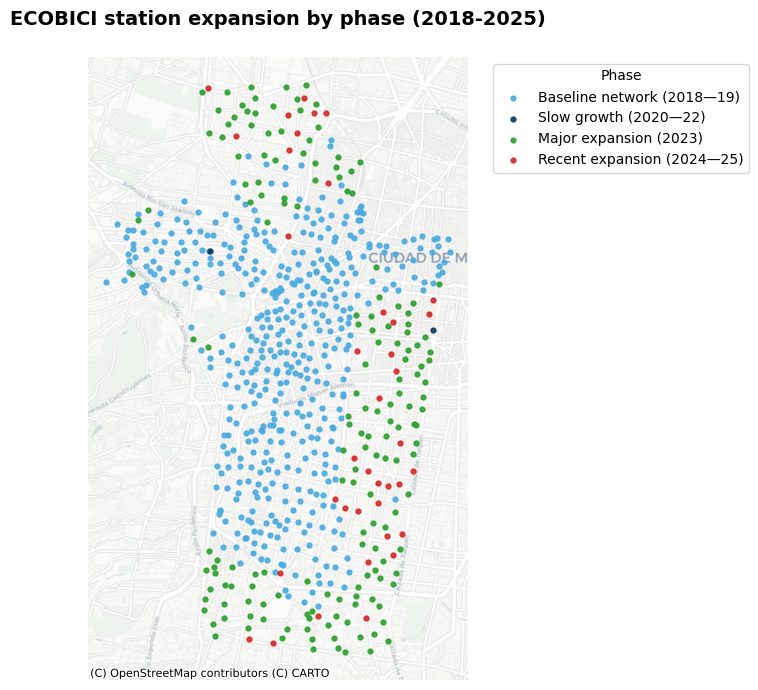

In [313]:
# mapping 
import contextily as cx
import geopandas as gpd 

plot_df = station_panel.dropna(subset=["lat", "lon"]).copy()

gdf = gpd.GeoDataFrame(
    plot_df,
    geometry=gpd.points_from_xy(plot_df["lon"], plot_df["lat"]),
    crs="EPSG:4326"   # lat/lon
)

gdf = gdf.to_crs(epsg=3857)

color_map = {
    "Baseline network (2018—19)": "#4aabe0",   # blue
    "Slow growth (2020—22)": "#0a3a5d",   # light green
    "Major expansion (2023)": "#2ca02c",   # green
    "Recent expansion (2024—25)": "#d62728"         # red
}

phase_order = [
    "Baseline network (2018—19)",
    "Slow growth (2020—22)",
    "Major expansion (2023)",
    "Recent expansion (2024—25)"
]

fig, ax = plt.subplots(figsize=(7, 7))

for phase in phase_order:
    group = gdf[gdf["phase"] == phase]
    if not group.empty:
        group.plot(
            ax=ax,
            markersize=12,
            alpha=0.9,
            label=phase,
            color=color_map[phase]
        )

cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)

ax.set_title("ECOBICI station expansion by phase (2018-2025)", 
             fontsize=14, fontweight="bold", loc="center", pad=12)
ax.legend(title="Phase", bbox_to_anchor=(1.05, 1), loc="upper left")
ax.set_axis_off()

plt.tight_layout()
plt.show()
fig.savefig(
    "../outputs/station_expansion_phase.png",
    dpi=300,
    bbox_inches="tight"
)

- ECOBICI's network remained static between 2018 and 2022, including throughout COVID-19. This was followed by a major expansion in 2023, mainly extending towards southern neighborhoods. 
- Later growth in 2024 and 2025 appears to consolidate this expansion, with additional stations to the northern and eastern areas of the city.